# Basic Regression Demo

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('housing_demo.csv')
df.head()

,square_feet,bedrooms,age_years,distance_to_city_miles,price
0,2675,4,35,9.3,441400
1,3000,6,11,21.1,504800
2,750,1,27,8.9,90100
3,2925,5,69,15.3,398200
4,2075,4,0,26.8,345300


In [3]:
print('Rows and columns:', df.shape)
print(df.info())
df.describe().round(2)

Rows and columns: (240, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   square_feet             240 non-null    int64  
 1   bedrooms                240 non-null    int64  
 2   age_years               240 non-null    int64  
 3   distance_to_city_miles  240 non-null    float64
 4   price                   240 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 9.5 KB
None


,square_feet,bedrooms,age_years,distance_to_city_miles,price
count,240.00,240.00,240.00,240.00,240.00
mean,1911.25,3.25,36.11,18.40,280262.92
std,720.36,1.38,20.41,9.44,129942.61
min,650.00,1.00,0.00,1.10,65000.00
25%,1300.00,2.00,20.00,10.85,163600.00
50%,1950.00,3.00,34.50,19.45,289150.00
75%,2506.25,4.00,54.00,26.15,374525.00
max,3175.00,6.00,70.00,34.90,544200.00


In [4]:
feature_names = ['square_feet', 'bedrooms', 'age_years']

X = df[feature_names]
y = df['price']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (240, 3)
y shape: (240,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print('Training rows:', len(X_train))
print('Test rows:', len(X_test))

Training rows: 192
Test rows: 48


In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [7]:
coefficients = pd.Series(model.coef_, index=feature_names)

print('Intercept:', round(model.intercept_, 3))
print(coefficients.round(3))

Intercept: -7789.493
square_feet     159.079
bedrooms       5467.411
age_years      -897.874
dtype: float64


In [8]:
new_house = pd.DataFrame([{
    'square_feet': 1800,
    'bedrooms': 3,
    'age_years': 20
}])

prediction = model.predict(new_house)[0]

print(f'Predicted house price: ${prediction:,.0f}')

Predicted house price: $276,997


In [9]:
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
rmse = mean_squared_error(y_test, predictions) ** 0.5
r2 = r2_score(y_test, predictions)

print(f'MAE: ${mae:,.0f}')
print(f'RMSE: ${rmse:,.0f}')
print(f'R squared: {r2:.3f}')

MAE: $33,562
RMSE: $41,080
R squared: 0.914


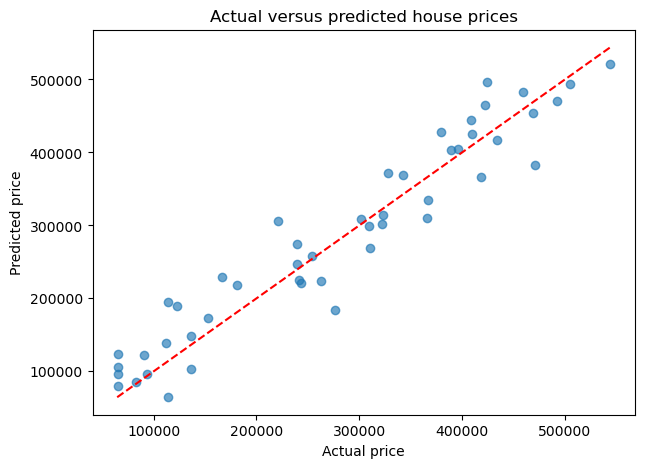

In [10]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, predictions, alpha=0.65)

low = min(y_test.min(), predictions.min())
high = max(y_test.max(), predictions.max())

plt.plot([low, high], [low, high], color='red', linestyle='--')

plt.xlabel('Actual price')
plt.ylabel('Predicted price')
plt.title('Actual versus predicted house prices')

plt.show()

In [11]:
new_feature_names = [
    'square_feet',
    'bedrooms',
    'age_years',
    'distance_to_city_miles'
]

X_new = df[new_feature_names]

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, y, test_size=0.20, random_state=42
)

new_model = LinearRegression()
new_model.fit(X_train_new, y_train_new)

new_predictions = new_model.predict(X_test_new)

new_rmse = mean_squared_error(y_test_new, new_predictions) ** 0.5

print(f'Original RMSE: ${rmse:,.0f}')
print(f'New RMSE: ${new_rmse:,.0f}')
print('Features used:', new_feature_names)

Original RMSE: $41,080
New RMSE: $26,429
Features used: ['square_feet', 'bedrooms', 'age_years', 'distance_to_city_miles']


## Model Comparison

The original model had an RMSE of $41,080. After adding distance_to_city_miles, the RMSE decreased to $26,429, so the new model performed better on the test data.

A lower test RMSE does not prove that the model is ready for deployment because this classroom dataset may not represent real-world housing data. More testing and validation would be needed before using the model for real-world predictions.